In [2]:
import numpy as np
import networkx as nx
import ot
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import os
import math
from EDRep import NodeEmbedding   
import random

Function that computes node embeddings for Graph A

In [3]:
def node_embedding(graph_a, partition_A, dim_embedding,seed=42):
    g_a = nx.to_scipy_sparse_array(graph_a, format='csr')
    # save the seed state
    rdn_state = np.random.get_state()
    random.seed(seed)
    np.random.seed(seed)
    embedding_a = NodeEmbedding(g_a, dim=dim_embedding, k=1, verbose=False)
    X_total = embedding_a.X
    X_list = [X_total[list(nodes), :] for nodes in partition_A]
    np.random.set_state(rdn_state)
    return X_list

Sampling function

In [4]:
def proportional_sample(X_list, partition, sample_fraction=0.6, seed=42):

    rng = np.random.default_rng(seed)
    samples_list = []
    
    for X in X_list:
        dim_class = X.shape[0]
        n_samples = int(np.round(dim_class * sample_fraction))
        
        # Optional?
        if dim_class > 0 and n_samples == 0:
            n_samples = 1
            
        if n_samples > 0:
            casual_index = rng.choice(dim_class, size=n_samples, replace=False)
            
            X_sampled = X[casual_index, :]
            samples_list.append(X_sampled)
        else:
            # If the original class was empty, we add an empty array
            samples_list.append(np.empty((0, X.shape[1])))
            
    return samples_list

Function that calculates the distance between two partitioned graphs using node embeddings and the Wasserstein distance between their block-wise scalar product distributions

In [ ]:
def w2_distance_classes_print(X_list,Y_list):
    # Validate the number of partitions
    m = len(X_list)
    if len(Y_list) != m:
        raise ValueError("The two graphs must have the same number of classes.")
    D = []
    distribution_data = {}

    # for cycles for the upper triangular part and diagonal blocks
    for i in range(m):
        for j in range(i, m):
            # Compute the dot product between class i and class j
            A_block = X_list[i] @ X_list[j].T
            B_block = Y_list[i] @ Y_list[j].T

            if i == j:
                if len(A_block)>1:
                    # If we are on a diagonal block, we take only the upper triangular part, excluding the main diagonal fixing k=1
                    upper_tri_indices_A = np.triu_indices_from(A_block, k=1)
                    upper_tri_indices_B= np.triu_indices_from(B_block, k=1)
                    vals_A = A_block[upper_tri_indices_A]
                    vals_B = B_block[upper_tri_indices_B]
                else:
                    # Il blocco è 1x1 o vuoto: non lo consideriamo
                    print(f" -> Skip the block ({i},{j})")
                    continue
            else:
                # For blocks outside the diagonal we take all the elements
                vals_A = A_block.flatten()
                vals_B = B_block.flatten()

            # Store the distributions for later visualization
            distribution_data[(i, j)] = (vals_A, vals_B)

            # Calculate the 1D Wasserstein distance between the two distributions
            wd2 = ot.wasserstein_1d(vals_A, vals_B, p=2)**(1/2)
            D.append(wd2)
            print(f" -> Distance between blocks ({i + 1},{j + 1}): {wd2:.7f}")
    # Convert the list of block distances into a NumPy array
    D_vector = np.array(D)

    # Calculate the final global distance as the Euclidean norm of the block distances vector
    finale_distance = np.linalg.norm(D_vector)

    return finale_distance, D_vector, distribution_data

In [5]:
def w2_distance_classes(X_list,Y_list):
    # Validate the number of partitions
    m = len(X_list)
    if len(Y_list) != m:
        raise ValueError("The two graphs must have the same number of classes.")
    D = []
    distribution_data = {}

    # For cycles for the upper triangular part and diagonal blocks
    for i in range(m):
        for j in range(i, m):
            # Compute the dot product between class i and class j
            A_block = X_list[i] @ X_list[j].T
            B_block = Y_list[i] @ Y_list[j].T

            if i == j:
                if len(A_block)>1:
                    # If we are on a diagonal block, we take only the upper triangular part, excluding the main diagonal fixing k=1
                    upper_tri_indices_A = np.triu_indices_from(A_block, k=1)
                    upper_tri_indices_B= np.triu_indices_from(B_block, k=1)
                    vals_A = A_block[upper_tri_indices_A]
                    vals_B = B_block[upper_tri_indices_B]
                else:
                    continue
            else:
                # For blocks outside the diagonal we take all the elements
                vals_A = A_block.flatten()
                vals_B = B_block.flatten()

             # Store the distributions for later visualization
            distribution_data[(i, j)] = (vals_A, vals_B)

            # Calculate the 1D Wasserstein distance between the two distributions
            wd2 = ot.wasserstein_1d(vals_A, vals_B, p=2)**(1/2)
            D.append(wd2)
    # Convert the list of block distances into a NumPy array
    D_vector = np.array(D)

    # Calculate the final global distance as the Euclidean norm of the block distances vector
    finale_distance = np.linalg.norm(D_vector)

    return finale_distance, D_vector, distribution_data

Function that generates a heatmap of the distances.

In [6]:
def plot_wasserstein_heatmap(distance_vector, m):

    distances_matrix = np.zeros((m, m))

    # 1. Reconstructing the symmetric matrix from the distance vector
    idx = 0
    for i in range(m):
        for j in range(i, m):
            distances_matrix[i, j] = distance_vector[idx]
            distances_matrix[j, i] = distance_vector[idx] 
            idx += 1

    # 2. Generating the heatmap
    plt.figure(figsize=(8, 6))

    sns.heatmap(distances_matrix,
                annot=True,
                cmap="YlOrRd",
                fmt=".7f",
                linewidths=.5,
                xticklabels=[f"Class {i + 1}" for i in range(m)],
                yticklabels=[f"Class {i + 1}" for i in range(m)])

    plt.title("Heatmap of Wasserstein Distances Between Classes: Full graph", pad=20)
    plt.xlabel("Graph 2")
    plt.ylabel("Graph 1")
    plt.tight_layout()
    plt.show()

Function that generate an mxm matrix containing all the KDE plots for the distributions being compared.

In [ ]:
def plot_dist_grid(distribution_data, m):
    # Create an m × m grid
    fig, axes = plt.subplots(m, m, figsize=(12, 12))

    for i in range(m):
        for j in range(m):
            ax = axes[i, j]

            #We draw only the upper triangular part

            if j >= i:
                dist_A, dist_B = distribution_data[(i, j)]

                # KDE plot of both graphs
                sns.kdeplot(dist_A, fill=True, ax=ax, color="blue", alpha=0.5, label="Grafo A")
                sns.kdeplot(dist_B, fill=True, ax=ax, color="orange", alpha=0.5, label="Grafo B")

                ax.set_title(f"Block ({i + 1} vs {j + 1})")
                ax.set_xlabel("Scalar product")

                if j == i:
                    ax.set_ylabel("Densità")
                else:
                    ax.set_ylabel("")

                if i == 0 and j == 0:
                    ax.legend()
            else:
                ax.axis('off')

    plt.suptitle("Complete Comparison of Distributions for Each Block", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [7]:
class_sizes = [500, 700, 300]

matrix_1 = np.where(np.eye(3, dtype=bool), 0.7, 0.2)

G_1 = nx.stochastic_block_model(class_sizes, matrix_1 , seed=41)
G_2 = nx.stochastic_block_model(class_sizes, matrix_1 , seed=44)


In [10]:
embedding_dim= 32
def partition(class_sizes):
    part = []
    start = 0
    for i in class_sizes:
        part.append(list(range(start, start + i)))
        start += i
    return part

partitions= partition(class_sizes)
emb_1 = node_embedding(G_1, partitions, embedding_dim)
emb_2 = node_embedding(G_2, partitions, embedding_dim)

In [53]:
X, Y = emb_1[0], emb_2[0]

A_block = X @ X.T
B_block = Y @ Y.T
upper_tri_indices_A = np.triu_indices_from(A_block, k=1)
upper_tri_indices_B= np.triu_indices_from(B_block, k=1)
vals_A = A_block[upper_tri_indices_A]
vals_B = B_block[upper_tri_indices_B]

wd2 = ot.wasserstein_1d(vals_A, vals_B, p=2)**(1/2)

wd2

np.float64(0.006308735366731798)

In [84]:
N1, _ = X.shape
N2, _ = Y.shape
alpha = 0.1

f = []

for i in range(100):

    print(f'i: {i+1}', end = '\r')
    idx1, idx2 = np.random.choice(np.arange(N1), int(N1**2*alpha)), np.random.choice(np.arange(N1), int(N1**2*alpha))
    id_ = idx1 != idx2
    idx1, idx2 = idx1[id_], idx2[id_]
    m1 = np.sum(X[idx1] * X[idx2], axis = 1)

    idx1, idx2 = np.random.choice(np.arange(N2), int(N2**2*alpha)), np.random.choice(np.arange(N2), int(N2**2*alpha))
    id_ = idx1 != idx2
    idx1, idx2 = idx1[id_], idx2[id_]
    m2 = np.sum(Y[idx1] * Y[idx2], axis = 1)
    

    f.append(ot.wasserstein_1d(m1, m2, p = 2)**(0.5))

In [85]:
# alpha = 0.05
# idx1, idx2 = np.random.choice(np.arange(N1), int(N1**2*alpha)), np.random.choice(np.arange(N1), int(N1**2*alpha))
# id_ = idx1 != idx2
# idx1, idx2 = idx1[id_], idx2[id_]
# m1 = np.sum(X[idx1] * X[idx2], axis = 1)


In [86]:
# plt.hist(vals_A, cumulative=True, density = True, bins = 100, alpha = 0.7)
# plt.hist(m1, cumulative = True, density = True, bins = 100, alpha = .7)
# plt.show();

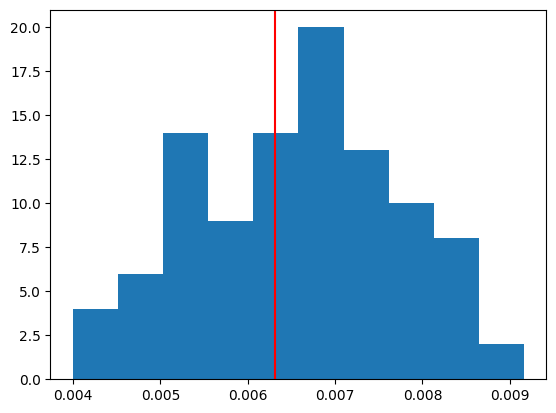

In [87]:
plt.hist(f)
plt.axvline(wd2, color = 'r')

In [32]:
sample_emb_1_06=proportional_sample(emb_1,partitions,sample_fraction=0.6)
sample_emb_2_06=proportional_sample(emb_2,partitions,sample_fraction=0.6)

In [9]:
sample_emb_1_07=proportional_sample(emb_1,partitions,sample_fraction=0.7)
sample_emb_2_07=proportional_sample(emb_2,partitions,sample_fraction=0.7)

In [10]:
sample_emb_1_08=proportional_sample(emb_1,partitions,sample_fraction=0.8)
sample_emb_2_08=proportional_sample(emb_2,partitions,sample_fraction=0.8)

In [11]:
sample_emb_1_09=proportional_sample(emb_1,partitions,sample_fraction=0.9)
sample_emb_2_09=proportional_sample(emb_2,partitions,sample_fraction=0.9)

In [16]:
d12,vec12,dist12=w2_distance_classes(emb_1,emb_2)
d12_06,vec12_06,dist12_06=w2_distance_classes(sample_emb_1_06,sample_emb_2_06)
d12_07,vec12_07,dist12_07=w2_distance_classes(sample_emb_1_07,sample_emb_2_07)
d12_09,vec12_09,dist12_09=w2_distance_classes(sample_emb_1_09,sample_emb_2_09)
d12_08,vec12_08,dist12_08=w2_distance_classes(sample_emb_1_08,sample_emb_2_08)

In [17]:
print(d12)
print(d12_09)
print(d12_08)
print(d12_07)
print(d12_06)

0.009608357632451055
0.009610710034184733
0.0077742248010241625
0.01153989978822831
0.01000933077123923


In [1]:
plot_wasserstein_heatmap(vec12,3)

NameError: name 'plot_wasserstein_heatmap' is not defined

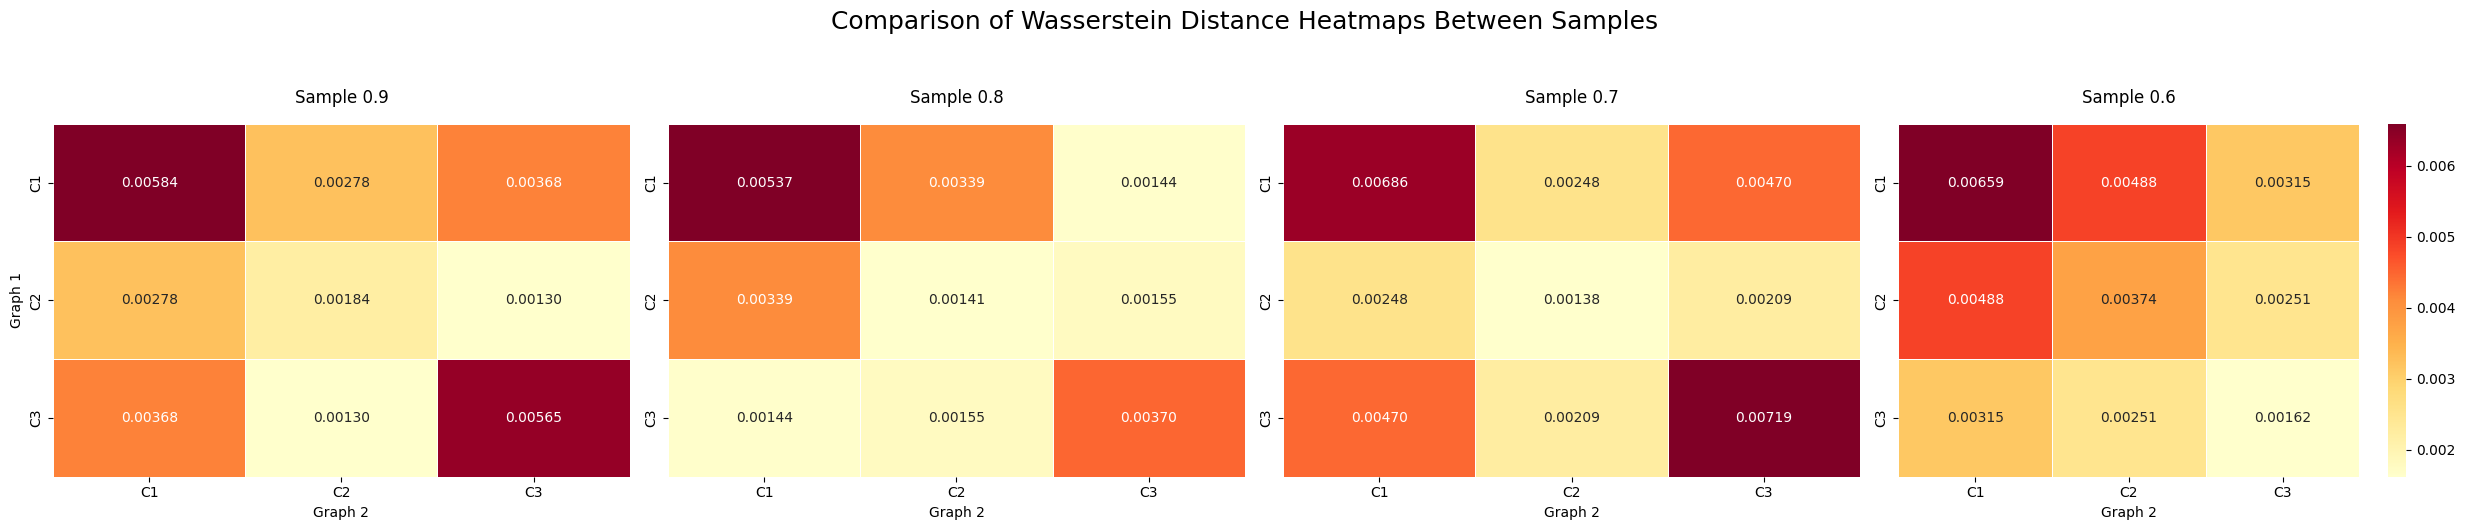

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Raccogliamo tutti i risultati in un dizionario per comodità
# Assicurati di aver già eseguito le celle che generano questi vettori
campionamenti = {
    "Sample 0.9": vec12_09,
    "Sample 0.8": vec12_08,
    "Sample 0.7": vec12_07,
    "Sample 0.6": vec12_06
}

m = len(class_sizes) # Nel tuo caso è 3

# Creiamo una figura con 1 riga e 5 colonne di grafici
fig, axes = plt.subplots(1, 4, figsize=(25, 5)) 

for ax, (titolo, distance_vector) in zip(axes, campionamenti.items()):
    
    distances_matrix = np.zeros((m, m))

    # 1. Ricostruzione della matrice simmetrica dal vettore
    idx = 0
    for i in range(m):
        for j in range(i, m):
            distances_matrix[i, j] = distance_vector[idx]
            distances_matrix[j, i] = distance_vector[idx] 
            idx += 1

    # 2. Generazione della heatmap sull'asse specifico (ax)
    sns.heatmap(distances_matrix,
                annot=True,
                cmap="YlOrRd",
                fmt=".5f",           # Riduco leggermente i decimali per non sovrapporre il testo
                linewidths=.5,
                xticklabels=[f"C{i + 1}" for i in range(m)],
                yticklabels=[f"C{i + 1}" for i in range(m)],
                ax=ax,
                cbar=(titolo == "Sample 0.6")) # Mostra la colorbar solo sull'ultimo grafico a destra per pulizia

    ax.set_title(titolo, pad=15)
    ax.set_xlabel("Graph 2")
    
    # Mostriamo l'etichetta dell'asse Y solo per il primo grafico a sinistra
    if ax == axes[0]:
        ax.set_ylabel("Graph 1")
    else:
        ax.set_ylabel("")

# Aggiungiamo un titolo generale alla figura
plt.suptitle("Comparison of Wasserstein Distance Heatmaps Between Samples", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

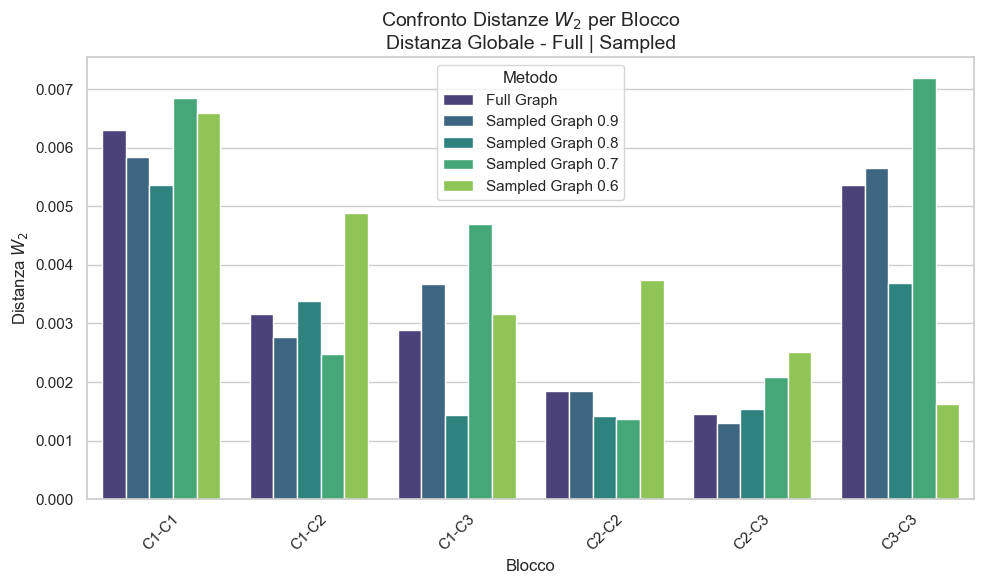

In [25]:

m = len(class_sizes) # Nel tuo caso è 3
labels = []
for i in range(m):
    for j in range(i, m):
        labels.append(f"C{i+1}-C{j+1}")

# Creiamo un DataFrame per confrontare D_vector_full e D_vector_sampled
df_distances = pd.DataFrame({
    'Blocco': labels,
    'Full Graph': vec12,
    'Sampled Graph 0.9': vec12_09,
    'Sampled Graph 0.8': vec12_08,
    'Sampled Graph 0.7': vec12_07,
    'Sampled Graph 0.6': vec12_06
})

# Calcoliamo l'errore
df_distances['Errore Assoluto9'] = np.abs(df_distances['Full Graph'] - df_distances['Sampled Graph 0.9'])
df_distances['Errore Assoluto8'] = np.abs(df_distances['Full Graph'] - df_distances['Sampled Graph 0.8'])
df_distances['Errore Assoluto7'] = np.abs(df_distances['Full Graph'] - df_distances['Sampled Graph 0.7'])
df_distances['Errore Assoluto5'] = np.abs(df_distances['Full Graph'] - df_distances['Sampled Graph 0.6'])

# 'Sciogliamo' il dataframe per Seaborn
df_melted = df_distances.melt(id_vars='Blocco', 
                              value_vars=['Full Graph', 'Sampled Graph 0.9', 'Sampled Graph 0.8', 'Sampled Graph 0.7', 'Sampled Graph 0.6'],
                              var_name='Metodo', value_name='Distanza W2')


# --- 3. CREAZIONE DEI GRAFICI ---
sns.set_theme(style="whitegrid")

# Creiamo una singola figura con un solo asse (ax)
fig, ax = plt.subplots(figsize=(10, 6))

# GRAFICO 1: Barplot comparativo delle distanze di Wasserstein (D_vector)
sns.barplot(data=df_melted, x='Blocco', y='Distanza W2', hue='Metodo', palette='viridis', ax=ax)

# Usiamo 'ax' al posto di 'axes[0]'
ax.set_title(f'Confronto Distanze $W_2$ per Blocco\nDistanza Globale - Full | Sampled', fontsize=14)
ax.set_ylabel('Distanza $W_2$')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

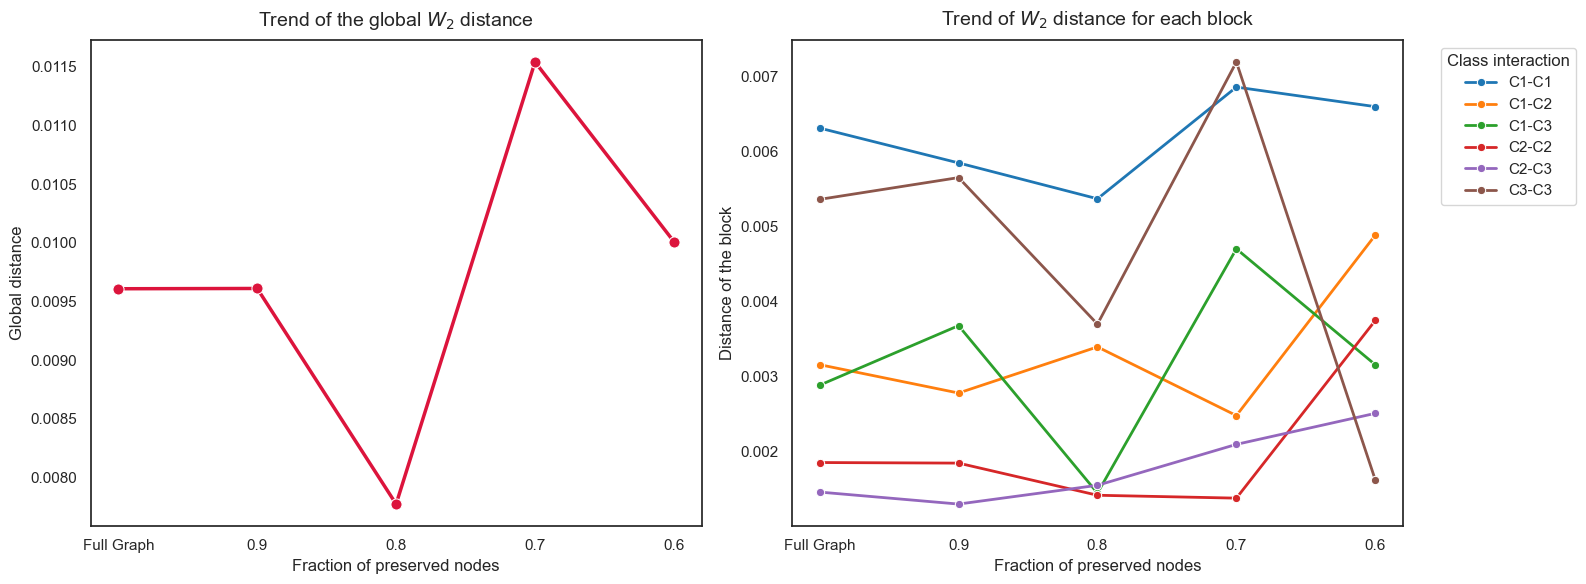

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# 1. Usa 'Blocco' al posto di 'Block' per selezionare la colonna
df_trend = df_distances[['Blocco', 'Full Graph', 'Sampled Graph 0.9', 
                         'Sampled Graph 0.8', 'Sampled Graph 0.7', 'Sampled Graph 0.6']]

# 2. Usa 'Blocco' anche qui
df_trend.columns = ['Blocco', 'Full Graph', '0.9', '0.8', '0.7', '0.6']

# 3. E infine usa 'Blocco' come id_vars nel melt
df_trend_melted = df_trend.melt(id_vars='Blocco', var_name='Sampling Fraction', value_name='W2 Distance')

# --- CREAZIONE DEI GRAFICI ---
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Trend della Distanza Globale
sns.lineplot(x=fractions, y=global_distances, marker='o', ax=axes[0], color='crimson', linewidth=2.5, markersize=8)
axes[0].set_title('Trend of the global $W_2$ distance', fontsize=14, pad=10)
axes[0].set_xlabel('Fraction of preserved nodes')
axes[0].set_ylabel('Global distance')
#axes[0].invert_xaxis() # Invertiamo l'asse X così si legge da 1.0 scendendo a 0.5

# Grafico 2: Trend per Singolo Blocco
sns.lineplot(data=df_trend_melted, x='Sampling Fraction', y='W2 Distance', 
             hue='Blocco', marker='o', ax=axes[1], palette='tab10', linewidth=2)
axes[1].set_title('Trend of $W_2$ distance for each block', fontsize=14, pad=10)
axes[1].set_xlabel('Fraction of preserved nodes')
axes[1].set_ylabel('Distance of the block')
#axes[1].invert_xaxis() # Invertiamo l'asse X per coerenza
axes[1].legend(title='Class interaction', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()